# Business impact simulation

Question: if the sales team can only follow up with a limited number of customers, how much more efficient is it to prioritize with the model?

Assumptions (can be changed)
- One follow-up takes about 5 minutes of sales time.
- The sales team can contact 20% of customers.
- Results use the test set (Sep to Nov 2011): 16,269 customer-cutoff rows, 3,647 of which are repeat orders (base rate 22.4%).

In [1]:
import sys
sys.path.append("..")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/dataset.parquet")
cuts = sorted(df["cutoff"].unique())
test = df[df["cutoff"].isin(cuts[15:])].copy()

art = joblib.load("../data/processed/model.pkl")
model, feats = art["model"], art["features"]
test["score"] = model.predict_proba(test[feats])[:, 1]

In [2]:
MINUTE_PER_CONTACT = 5
CAPACITY = 0.20

n = len(test)
total_repeat = test["target"].sum()
base_rate = total_repeat / n
k = int(n * CAPACITY)
print(n, total_repeat, round(base_rate, 3), k)

16269 3647 0.224 3253


In [4]:
def scenario(name, contacts, reached):
    return {"scenario": name,
            "contacts": int(contacts),
            "repeat_reached": int(round(reached)),
            "contacts_per_repeat": round(contacts / reached, 2),
            "hours": round(contacts * MINUTE_PER_CONTACT / 60)}
    
top = test.sort_values("score", ascending=False).head(k)

rows = [
    scenario("Contact Everyone", n, total_repeat),
    scenario("random 20%", k, k * base_rate),
    scenario("Model top 20%", k, top["target"].sum())
]
pd.DataFrame(rows)

,scenario,contacts,repeat_reached,contacts_per_repeat,hours
0,Contact Everyone,16269,3647,4.46,1356
1,random 20%,3253,729,4.46,271
2,Model top 20%,3253,1790,1.82,271


In [5]:
reached_model = top["target"].sum()
contacts_random_same_reached = reached_model / base_rate
saving = 1 - k / contacts_random_same_reached
print(round(contacts_random_same_reached), f"{saving:.0%}")

7985 59%


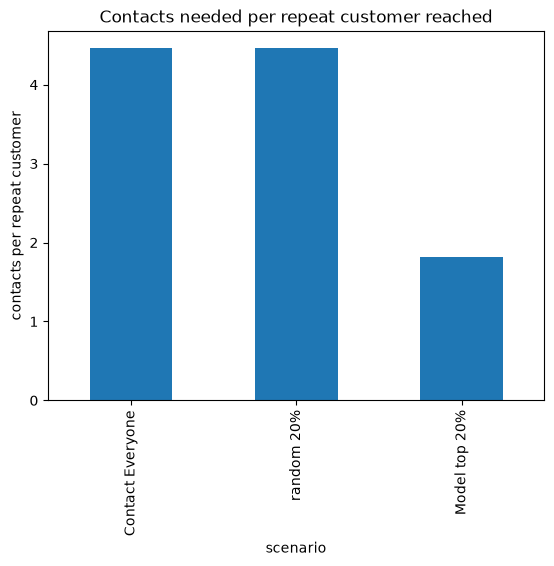

In [7]:
res = pd.DataFrame(rows).set_index("scenario")
res["contacts_per_repeat"].plot(kind="bar", title="Contacts needed per repeat customer reached")
plt.ylabel("contacts per repeat customer")
plt.show()

In [8]:
r = test["score"].rank(method="first", ascending=False) / len(test)
test["segment"] = pd.cut(r, [0, 0.2, 0.5, 1.0], labels=["High", "Medium", "Low"])
seg = test.groupby("segment", observed=True).agg(
    customers=("target", "size"), repeaters=("target", "sum"), repeat_rate=("target", "mean"))
seg["repeat_rate"] = seg["repeat_rate"].round(3)
seg["share_of_repeators"] = (seg["repeaters"] / total_repeat). round(3)
seg

,customers,repeaters,repeat_rate,share_of_repeators
segment,,,,
High,3253,1790,0.550,0.491
Medium,4881,1176,0.241,0.322
Low,8135,681,0.084,0.187


**Findings**
- With the same effort (about 271 hours at 5 minutes per contact), the model reaches 1,790 repeat customers versus about 729 with random selection (2.5 times more).
- Contacts needed per repeat customer drop from 4.46 to 1.82.
- To reach the same number of repeat customers (about 1,790), random selection would need about 7,985 contacts versus 3,253 with the model: roughly 59% fewer contacts.
- Segments: High (top 20%) repeats 55% of the time and holds 49% of all repeat customers; Low (bottom 50%) holds only 19%.

**Limitations**
- The model predicts who is likely to reorder, not who will reorder because of a follow-up. Some of these customers would have reordered anyway. The real effect of follow-up needs an A/B test (contact vs. no contact within the same segment).
- The 5-minute cost per contact and the 20% capacity are assumptions, not measured values.